# Baseline Channel Charting

## Set Up Environment

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
import numpy as np

from scenario2_utils import (
    DEFAULT_SEED,
    affine_transform_channel_chart,
    build_csi_features,
    fit_channel_chart,
    load_dataset_artifacts,
    plot_cdf,
    plot_cdf_2d,
    plot_spatial_colorized_positions,
    set_random_seeds,
 )

set_random_seeds(DEFAULT_SEED, tf_module=tf)

E0000 00:00:1776284269.110579     559 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776284269.117599     559 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776284269.135038     559 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284269.135056     559 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284269.135058     559 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284269.135060     559 computation_placer.cc:177] computation placer already registered. Please check linka

## Load Data

In [2]:
dataset = load_dataset_artifacts(include_geometry=True)
dissimilarity_matrix_geodesic_meters = np.load("results/dissimilarity_matrix_geodesic_meters.npy")
csi_freq_domain_train = dataset.csi_freq_domain_train
groundtruth_positions_train = dataset.groundtruth_positions_train
array_positions_3D = dataset.array_positions_3d

print("Shape of csi_freq_domain_train: ", csi_freq_domain_train.shape)
print("Shape of groundtruth_positions_train: ", groundtruth_positions_train.shape)
print("Shape of array_positions_3D: ", array_positions_3D.shape)

Shape of csi_freq_domain_train:  (5000, 5, 4, 2, 4, 64)
Shape of groundtruth_positions_train:  (5000, 3)
Shape of array_positions_3D:  (5, 4, 3)


### Build CSI Features

In [3]:
_, _, csi_features = build_csi_features(csi_freq_domain_train)

print(csi_features.shape)

(5000, 20, 16, 16, 2)


## Learn the Channel Chart

### Configure and Train the Charting Model

In [4]:
channel_chart_positions = fit_channel_chart(
    csi_features,
    dissimilarity_matrix_geodesic_meters,
    embedding_dim=3,
    seed_a=DEFAULT_SEED,
    seed_b=DEFAULT_SEED + 1,
 )

I0000 00:00:1776284306.777026     559 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22290 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:c1:00.0, compute capability: 8.9



Training Session  1 
Batch Size:  400 
Learning rate:  0.005


I0000 00:00:1776284313.136980     657 service.cc:152] XLA service 0x7082840034c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776284313.137017     657 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
I0000 00:00:1776284313.846312     657 cuda_dnn.cc:529] Loaded cuDNN version 90300


 16/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 38.7302

I0000 00:00:1776284316.443837     657 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 12.5811

Training Session  2 
Batch Size:  800 
Learning rate:  0.002
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 2.4076

Training Session  3 
Batch Size:  1200 
Learning rate:  0.001
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 1.8261

Training Session  4 
Batch Size:  2000 
Learning rate:  0.001
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 1.6369

Training Session  5 
Batch Size:  3000 
Learning rate:  0.0005
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 1.5457

Training Session  6 
Batch Size:  3000 
Learning rate:  0.0001
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 1.5070

Training Session  7 
Batch Size:  4000 
Learning rate:  5e-05
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 1.5032

Training Session  8 
Batch Size:  5000 
Learning rate:  1e-05
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 1.5019
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


## Evaluate and Visualize Results

### Evaluate on the Training Set

### Evaluation Note

This baseline is evaluated as a single global 3D chart after one global affine alignment to all samples.

The multistory method uses a different evaluation protocol because floor classification is part of that method. Its final metrics are computed after floor-wise processing and floor-wise 2D alignment.

The resulting numbers should therefore be interpreted as a comparison of complete methods, not as a strictly protocol-identical ablation of the charting stage alone.

### Predict, Align, and Visualize the Final Chart

In [5]:
channel_chart_positions_transformed = affine_transform_channel_chart(
    groundtruth_positions_train,
    channel_chart_positions,
 )

In [6]:
np.save("results/channel_chart_positions_baseline.npy", channel_chart_positions)
np.save("results/channel_chart_positions_baseline_transformed.npy", channel_chart_positions_transformed)

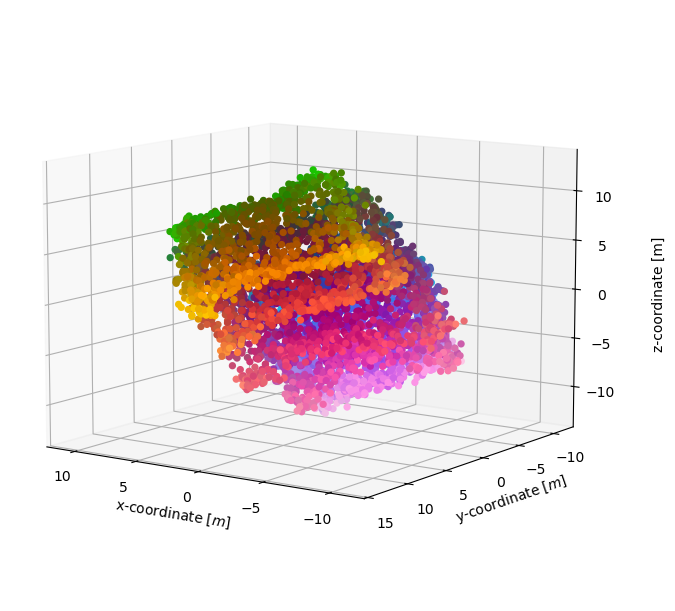

In [7]:
plot_spatial_colorized_positions(
    channel_chart_positions,
    groundtruth_positions_train,
    save_path="results/cc_positions_baseline.png",
 )

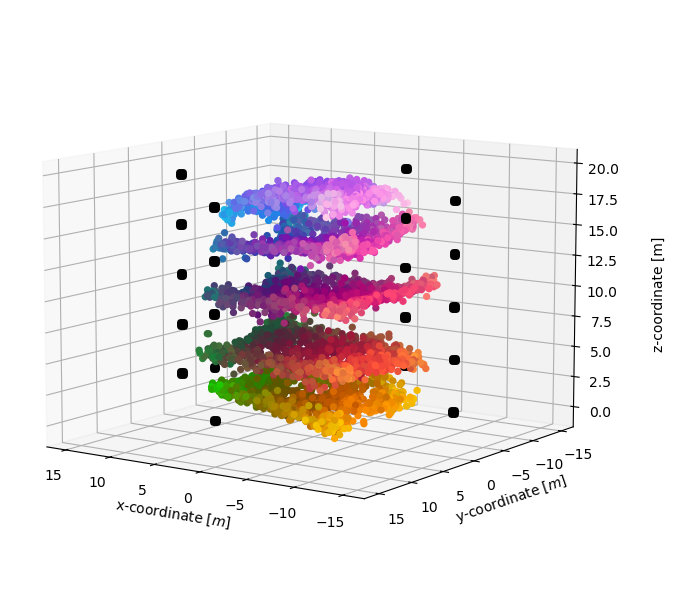

In [8]:
plot_spatial_colorized_positions(
    channel_chart_positions_transformed,
    groundtruth_positions_train,
    save_path="results/cc_positions_baseline_transformed.png",
    array_positions_3d=array_positions_3D,
 )

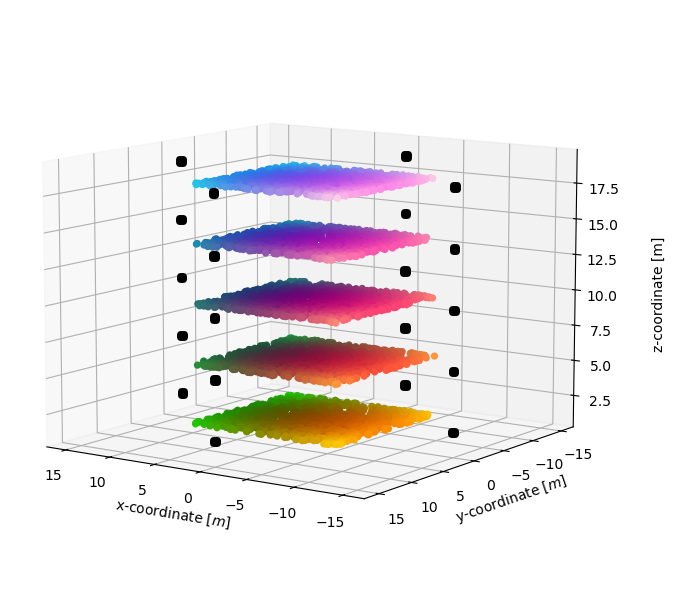

In [9]:
plot_spatial_colorized_positions(
    groundtruth_positions_train,
    groundtruth_positions_train,
    save_path="results/groundtruth_positions_multistory_building_colorized.png",
    array_positions_3d=array_positions_3D,
 )

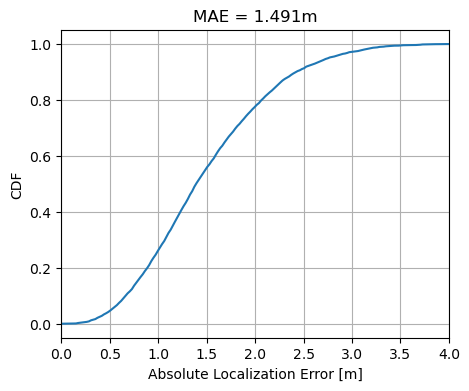

In [10]:
plot_cdf(channel_chart_positions_transformed, groundtruth_positions_train, title = "Training Set")

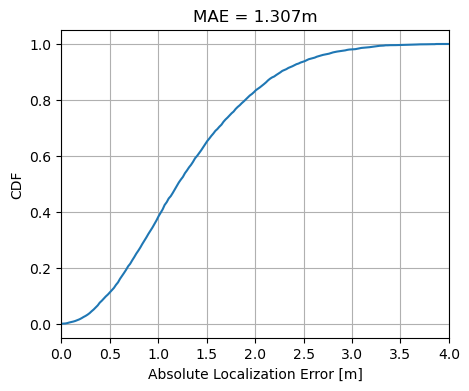

In [11]:
plot_cdf_2d(channel_chart_positions_transformed[:, :2], groundtruth_positions_train[:, :2], title="Training Set - 2D errors")